### Velo Nantes

## Velo Otages Prediction

In [18]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [19]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import learning_curve, train_test_split, cross_val_score

In [20]:
from velodata.data import VeloData

# Initialisation
api = VeloData()
api.ping()

pong


### 1. Chargement des données.

URL complète pour Nantes (format csv)

In [31]:
from velodata.fluxes import Flux

# 1. Instanciation (charge les données en mémoire)
gestionnaire_flux = Flux()

# 2. Création de la pipeline de traitement
df_50_otages = gestionnaire_flux.pick_station(station_name='786 - 50 Otages Vers Nord')
df_50_otages.head(3)

Initialisation de l'objet Flux...
Tentative de téléchargement depuis l'API...
Succès ! 135803 lignes chargées.
Station sélectionnée : 786 - 50 Otages Vers Nord (2324 jours trouvés).


,Numéro de boucle,Jour,00,01,02,03,04,05,06,07,...,20,21,22,23,Total,Probabilité de présence d'anomalies,Jour de la semaine,Boucle de comptage,Date formatée,Vacances
8,786,2026-05-12,8.0,4.0,0.0,2.0,2.0,6.0,20.0,141.0,...,177.0,99.0,103.0,62.0,3741,NaN,2,786 - 50 Otages Vers Nord,2026-05-12,Hors Vacances
87,786,2026-05-11,9.0,3.0,2.0,0.0,2.0,5.0,12.0,89.0,...,133.0,80.0,65.0,31.0,2688,NaN,1,786 - 50 Otages Vers Nord,2026-05-11,Hors Vacances
152,786,2026-05-10,38.0,44.0,29.0,17.0,14.0,7.0,5.0,8.0,...,52.0,25.0,24.0,16.0,840,NaN,7,786 - 50 Otages Vers Nord,2026-05-10,Hors Vacances


In [35]:
from velodata.fluxes import Flux

df_50_otages = gestionnaire_flux.horodate(df_50_otages)
display(df_50_otages.head())

#
# # Ici, attention, si c'est un cumul JOURNALIER, max_threshold doit être élevé (ex: 8000)
# df_clean = gestionnaire_flux.review_quality(df_50_otages, target_col='Total', max_threshold=10000)


KeyError: 'Date formatée'

In [27]:
display(df_50_otages.head(3))

# df_raw.groupby('Boucle de comptage')['Numéro de boucle'].count()
print(df_raw.columns.tolist())

AttributeError: 'NoneType' object has no attribute 'head'

In [ ]:
url_csv = "https://data.nantesmetropole.fr/api/explore/v2.1/catalog/datasets/244400404_comptages-velo-nantes-metropole/exports/csv?lang=fr&timezone=Europe%2FParis&use_labels=true&delimiter=%3B"
# sep = ;


Index(['Unnamed: 0', 'Numéro de boucle', 'Jour', '00', '01', '02', '03', '04',
       '05', '06', '07', '08', '09', '10', '11', '12', '13', '14', '15', '16',
       '17', '18', '19', '20', '21', '22', '23', 'Total',
       'Probabilité de présence d'anomalies', 'Jour de la semaine',
       'Boucle de comptage', 'Date formatée', 'Vacances'],
      dtype='object')


### 2. Exploration Nettoyage préliminaire 

On renomme pour avoir des noms de colonnes faciles à manipuler.

Exploration rapide des données

In [ ]:
df_50_otages = gestionnaire_flux.drop_hours(df_50_otages)

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 2324 entries, 2020-01-01 00:00:00+00:00 to 2026-05-12 00:00:00+00:00
Data columns (total 31 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   Numéro de boucle                     2324 non-null   int64  
 1   Jour                                 2324 non-null   object 
 2   00                                   2298 non-null   float64
 3   01                                   2298 non-null   float64
 4   02                                   2293 non-null   float64
 5   03                                   2298 non-null   float64
 6   04                                   2299 non-null   float64
 7   05                                   2299 non-null   float64
 8   06                                   2298 non-null   float64
 9   07                                   2299 non-null   float64
 10  08                                   2301 non-nu

,Numéro de boucle,Jour,Total,Probabilité de présence d'anomalies,Jour de la semaine,Boucle de comptage,Vacances
datetime_index,,,,,,,
2020-01-01 00:00:00+00:00,786,2020-01-01,581,NaN,3,786 - 50 Otages Vers Nord,Vacances de Noël
2020-01-02 00:00:00+00:00,786,2020-01-02,1705,NaN,4,786 - 50 Otages Vers Nord,Vacances de Noël
2020-01-03 00:00:00+00:00,786,2020-01-03,1874,NaN,5,786 - 50 Otages Vers Nord,Vacances de Noël
2020-01-04 00:00:00+00:00,786,2020-01-04,1629,NaN,6,786 - 50 Otages Vers Nord,Vacances de Noël
2020-01-05 00:00:00+00:00,786,2020-01-05,1074,NaN,7,786 - 50 Otages Vers Nord,Vacances de Noël
...,...,...,...,...,...,...,...
2026-05-08 00:00:00+00:00,786,2026-05-08,1864,NaN,5,786 - 50 Otages Vers Nord,Hors Vacances
2026-05-09 00:00:00+00:00,786,2026-05-09,1317,NaN,6,786 - 50 Otages Vers Nord,Hors Vacances
2026-05-10 00:00:00+00:00,786,2026-05-10,840,NaN,7,786 - 50 Otages Vers Nord,Hors Vacances


In [ ]:

df = df.drop(columns=['Unnamed: 0','Probabilité de présence d\'anomalies', 'Date formatée'])

print(f"Nombre total de lignes : {len(df)}")
print("\n--- Les 5 premières lignes ---")
df.head(5)

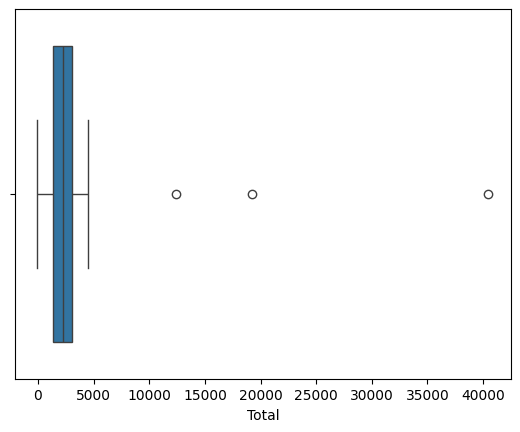

In [ ]:
# excluding
THRES = 10_000
sns.boxplot(data = df , x  = 'Total' )

# df.loc[df['Total'] > THRES, 'Total'] = np.nan
# df.loc[df['Total'] < 0, 'Total'] = np.nan
df.loc[(df['Total'] > THRES) | (df['Total'] < 0), 'Total'] = np.nan


df_clean = df.dropna(subset = ['Total'])


### Filter

 Filtrer sur UN seul compteur (Important !)
#Le fichier contient tous les compteurs de Nantes mélangés.
Isolons un compteur emblématique, ex: "50 Otages"
Listons d'abord les compteurs disponibles

count    2186.000000
mean     2160.345380
std      1049.623967
min         0.000000
25%      1326.250000
50%      2254.000000
75%      3044.750000
max      4479.000000
Name: Total, dtype: float64

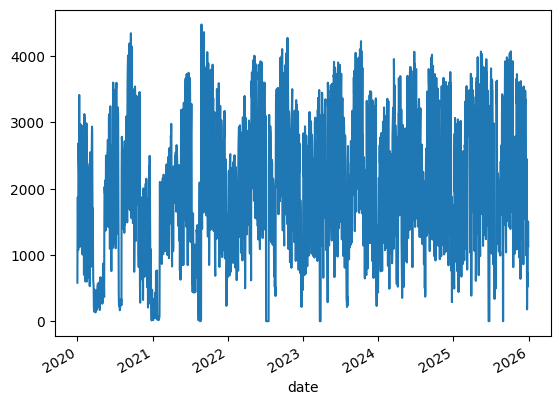

In [ ]:
df_clean['Total'].plot()
df_clean['Total'].describe()

<Axes: xlabel='Jour de la semaine', ylabel='Total'>

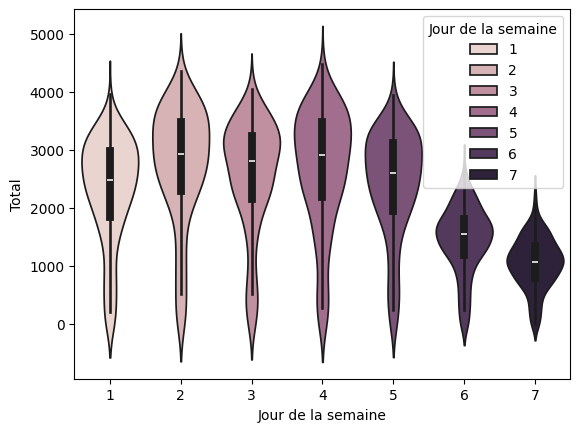

In [ ]:
sns.violinplot(data = df_clean, y= 'Total' ,  x = 'Jour de la semaine',
               hue = 'Jour de la semaine')

In [ ]:
df_clean['Mois'] = df_clean.index.month

# Nouvelle colonne: 'Ouvre'  : int
# Jour Ouvrés.  = 1 quand le jour est 1, 2, 3, 4 ou 5 et que l'on est hors vacances
df_clean['Ouvre'] = ((df_clean['Vacances'] == 'Hors Vacances') & (df_clean['Jour de la semaine'] <= 5)).astype(int)
# Verifier le type
df_clean['Ouvre'].dtypes

/tmp/ipykernel_259599/1405929832.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean['Mois'] = df_clean.index.month
/tmp/ipykernel_259599/1405929832.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean['Ouvre'] = ((df_clean['Vacances'] == 'Hors Vacances') & (df_clean['Jour de la semaine'] <= 5)).astype(int)


Numéro de boucle        int64
Jour                   object
00                    float64
01                    float64
02                    float64
03                    float64
04                    float64
05                    float64
06                    float64
07                    float64
08                    float64
09                    float64
10                    float64
11                    float64
12                    float64
13                    float64
14                    float64
15                    float64
16                    float64
17                    float64
18                    float64
19                    float64
20                    float64
21                    float64
22                    float64
23                    float64
Total                 float64
Jour de la semaine      int64
Boucle de comptage     object
Vacances               object
Mois                    int32
Ouvre                   int64
dtype: object

In [ ]:
df_clean['Vacances'].value_counts()
df_clean.groupby('Vacances')[['Vacances','Total']].agg({'Vacances' : 'count', 'Total' : 'mean'})


,Vacances,Total
Vacances,,
Hors Vacances,1440,2414.913889
Pont de l'Ascension,13,1366.769231
Vacances d'hiver,96,1715.270833
Vacances d'été,345,1749.600000
Vacances de Noël,98,1011.979592
Vacances de la Toussaint,96,1960.697917
Vacances de printemps,98,1750.938776


### Prepare the Model

In [ ]:
X = df_clean[['Mois','Jour de la semaine', 'Ouvre']]
X.info()

# COVID !!!  COVID !!!!

y = df_clean['Total']


model = LinearRegression()
model.fit(X, y)

model.score(X,y)

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 2186 entries, 2020-01-01 00:00:00+00:00 to 2025-12-31 00:00:00+00:00
Data columns (total 3 columns):
 #   Column              Non-Null Count  Dtype
---  ------              --------------  -----
 0   Mois                2186 non-null   int32
 1   Jour de la semaine  2186 non-null   int64
 2   Ouvre               2186 non-null   int64
dtypes: int32(1), int64(2)
memory usage: 59.8 KB


0.3936727730849141